In [1]:
# @title Import Libraries

import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import xgboost as xgb
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_error, mean_squared_log_error, r2_score
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# @title Read the Csv File
housing1 = pd.read_excel("DemooneCleaned.xlsm", engine="openpyxl")
housing1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 9 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Cement                              992 non-null    float64
 1   Blast Furnace Slag                  992 non-null    float64
 2   Fly Ash                             992 non-null    float64
 3   Water                               992 non-null    float64
 4   Superplasticizer                    992 non-null    float64
 5   Coarse Aggregate                    992 non-null    float64
 6   Fine Aggregate                      992 non-null    float64
 7   Age (day)                           992 non-null    int64  
 8   Concrete compressive strength(MPa)  992 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 69.9 KB


In [3]:
# @title Display the DataFrame Also add Feature using Feature engineering
# Load the DataFrame
housing1['Fine to Cement Ratio'] = housing1['Fine Aggregate'] / housing1['Cement']
housing1['Coarse to Cement Ratio'] = housing1['Coarse Aggregate'] / housing1['Cement']
# housing1.rename(columns={
#     'Fine Aggregate': 'Fine to Cement Ratio',
#     'Coarse Aggregate': 'Coarse to Cement Ratio'
# }, inplace=True)
# Add Water to Cement Ratio
housing1['Water to Cement Ratio'] = housing1['Water'] / housing1['Cement']
# Insert the new columns at the beginning
housing1.insert(0, 'Water to Cement Ratio', housing1.pop('Water to Cement Ratio'))
housing1.insert(1, 'Fine to Cement Ratio', housing1.pop('Fine to Cement Ratio'))
housing1.insert(2, 'Coarse to Cement Ratio', housing1.pop('Coarse to Cement Ratio'))
# Check the updated DataFrame
housing1.head()

,Water to Cement Ratio,Fine to Cement Ratio,Coarse to Cement Ratio,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength(MPa)
0,1.882353,9.235294,8.696078,102.0,153.0,0.0,192.0,0.0,887.0,942.0,3,4.57
1,1.882353,9.235294,8.696078,102.0,153.0,0.0,192.0,0.0,887.0,942.0,90,25.46
2,1.882353,9.235294,8.696078,102.0,153.0,0.0,192.0,0.0,887.0,942.0,7,7.68
3,1.882353,9.235294,8.696078,102.0,153.0,0.0,192.0,0.0,887.0,942.0,28,17.28
4,1.879040,7.839335,8.662973,108.3,162.4,0.0,203.5,0.0,938.2,849.0,28,20.59


In [4]:
housing1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Water to Cement Ratio               992 non-null    float64
 1   Fine to Cement Ratio                992 non-null    float64
 2   Coarse to Cement Ratio              992 non-null    float64
 3   Cement                              992 non-null    float64
 4   Blast Furnace Slag                  992 non-null    float64
 5   Fly Ash                             992 non-null    float64
 6   Water                               992 non-null    float64
 7   Superplasticizer                    992 non-null    float64
 8   Coarse Aggregate                    992 non-null    float64
 9   Fine Aggregate                      992 non-null    float64
 10  Age (day)                           992 non-null    int64  
 11  Concrete compressive strength(MPa)  992 non-n

In [5]:
# @title Making copy of original Data
# Create a copy of the original DataFrame to avoid modifying it directly
housing = housing1.copy()

In [6]:
# @title Data Clipping
# # Set all values in "Age(day)" greater than 28 to 28
# housing1.loc[housing1["Age(day)"] > 56, "Age(day)"] = 56

In [7]:
# @title Applying Transformation

# Apply transformations
housing['Cement_sqrt'] = np.sqrt(housing['Cement'])
housing['Age_log'] = np.log(housing['Age (day)'] + 1)  # Add 1 to avoid log(0)
housing['CoarseAggregate_log'] = np.log(housing['Coarse Aggregate'] + 1)
housing['Superplasticizer_sqrt'] = np.sqrt(housing['Superplasticizer'])
housing['Slag_sqrt'] = np.sqrt(housing['Blast Furnace Slag '])
housing['Water_square'] = housing['Water'] ** 2

# Drop original columns if you no longer need them
housing = housing.drop(columns=['Cement', 'Age (day)', 'Coarse Aggregate',
                                 'Superplasticizer', 'Blast Furnace Slag ', 'Water'])

# Rename transformed columns if required
# housing = housing.rename(columns={
#     'Cement_sqrt': 'Cement',
#     'Age_log': 'Age',
#     'CoarseAggregate_log': 'Coarse Aggregate',
#     'Superplasticizer_sqrt': 'Superplasticizer',
#     'Slag_sqrt': 'Blast Furnace Slag',
#     'Water_square': 'Water'
# })


In [8]:
# Define the column name
target_column = 'Concrete compressive strength(MPa)'

# Calculate Q1, Q3, and IQR
Q1 = housing[target_column].quantile(0.25)
Q3 = housing[target_column].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the DataFrame to remove outliers
housing_filtered = housing[(housing[target_column] >= lower_bound) & (housing[target_column] <= upper_bound)]
housing=housing_filtered.copy()

# Check the result
print(f"Original dataset size: {housing1.shape[0]}")
print(f"Filtered dataset size: {housing.shape[0]}")



# # # Save the filtered DataFrame to an Excel file
# # housing.to_excel("filtered_housing.xlsx", index=False)


Original dataset size: 992
Filtered dataset size: 983


Train RMSE: 0.43, Train R2: 1.00
Test RMSE: 3.92, Test R2: 0.94


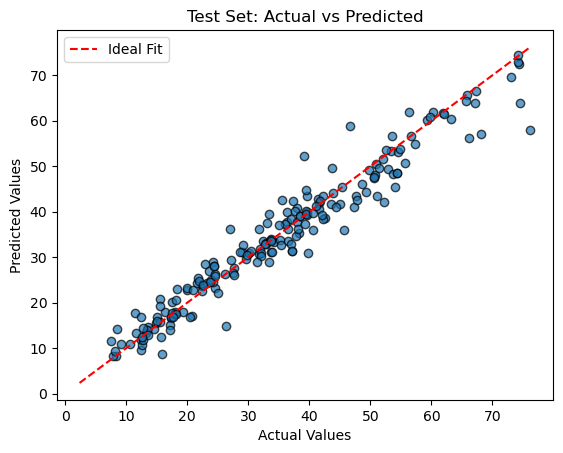

In [9]:
# @title Simple xgboost
# Split the data
X = housing.drop("Concrete compressive strength(MPa)", axis=1)
y = housing["Concrete compressive strength(MPa)"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the default XGBoost model
model = xgb.XGBRegressor()
model.fit(X_train, y_train)

# Predict on train and test data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Evaluate the model
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print evaluation metrics
print(f"Train RMSE: {train_rmse:.2f}, Train R2: {train_r2:.2f}")
print(f"Test RMSE: {test_rmse:.2f}, Test R2: {test_r2:.2f}")

# Plot actual vs. predicted values for test data
plt.scatter(y_test, y_test_pred, alpha=0.7, edgecolor='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Ideal Fit')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Test Set: Actual vs Predicted')
plt.legend()
plt.show()

In [10]:
xg_params = {
    "n_estimators": [800], 
    "learning_rate": [0.04],  
    "max_depth": [4],  
    "min_child_weight": [1],
    "subsample": [0.5], 
    "colsample_bytree": [0.7],
    "gamma": [0.1],  
    "reg_alpha": [0.1],
    "reg_lambda": [2]
}

In [11]:
from sklearn.model_selection import GridSearchCV


In [12]:
model_tuned = XGBRegressor()

In [13]:
xg_cv_model = GridSearchCV(model_tuned,xg_params,cv=5,n_jobs=-1)

In [14]:
%%time
xg_cv_model.fit(X_train,y_train)

CPU times: total: 5.66 s
Wall time: 8.38 s


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7], 'gamma': [0.1],
                         'learning_rate': [0.04], 'max_depth': [4],
                         'min_child_weight': [1], 'n_estimators': [800],
                         'reg_alpha': [0.1], 'reg_lambda': [2],
                         'subsample': [0.5]})

In [15]:
xg_cv_model.best_params_

{'colsample_bytree': 0.7,
 'gamma': 0.1,
 'learning_rate': 0.04,
 'max_depth': 4,
 'min_child_weight': 1,
 'n_estimators': 800,
 'reg_alpha': 0.1,
 'reg_lambda': 2,
 'subsample': 0.5}

In [16]:
# Make predictions on the test set
y_pred_values = xg_cv_model.predict(X_test)

# Example: Print the predictions
print(y_pred_values)

# Evaluate performance (optional)
from sklearn.metrics import mean_squared_error, r2_score

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred_values)
r2 = r2_score(y_test, y_pred_values)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")


[48.869347  37.261787  52.69425   35.380234  21.693655  30.651321
 37.98614   21.304934  17.260824  18.230406  25.223522  47.709187
 42.162155  49.20694   45.31483   26.012722  11.06492   20.7568
 22.387585  11.677888  17.224741  12.765208  32.53853   35.688847
 37.982777  40.63253   23.053677  55.74462   41.765446  50.449078
 18.40101   28.759092  12.149918  30.844322  35.470173  16.350382
 36.212357  43.92596   17.851555  14.995713  39.645195  43.879364
 49.73372   46.76025   19.521671  45.221924  40.957554  13.45599
 60.56831   33.619396  15.182992   9.984207  32.4189    31.24685
 13.983945  30.632717  31.038725  60.666733  19.161024  16.594498
 69.347824  31.984978  52.91718    7.7531595 21.418304  20.604908
 48.746304  38.04642   60.110565  29.807474  40.66642   37.875557
 53.00166   16.012478  36.236904  31.283377  31.152084  60.5866
 44.665962  39.694847  31.89691   28.333498  43.074482  70.33681
 56.10208   13.4789    38.04601   62.627953  61.608707  63.98575
 13.997385   6.790

In [33]:
print(f"Shape of y_test: {y_test.shape}")
print(f"Shape of y_pred_values: {y_pred_values.shape}")


Shape of y_test: (197,)
Shape of y_pred_values: (197,)


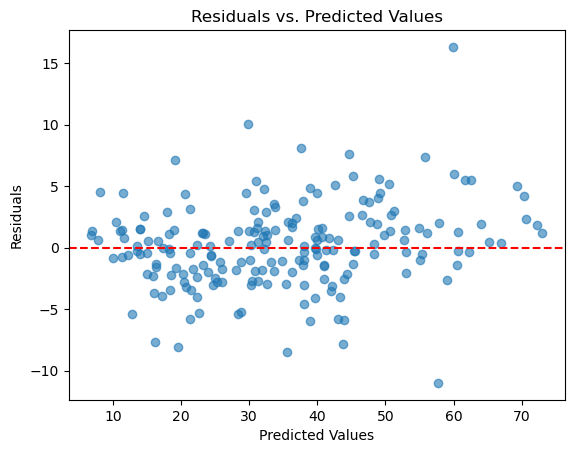

In [35]:
import matplotlib.pyplot as plt
residuals = y_test - y_pred_values

plt.scatter(y_pred_values, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values")
plt.show()


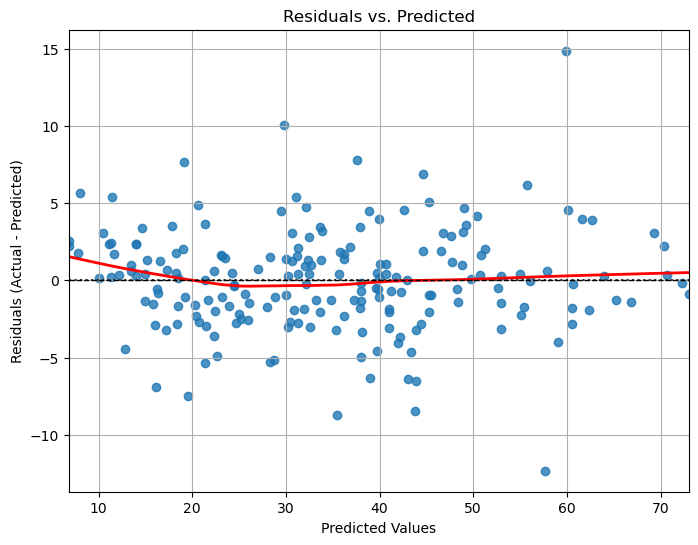

In [37]:
plt.figure(figsize=(8, 6))
sns.residplot(x=y_pred_values, y=residuals, lowess=True, line_kws={'color': 'red', 'lw': 2})
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residuals vs. Predicted')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.show()

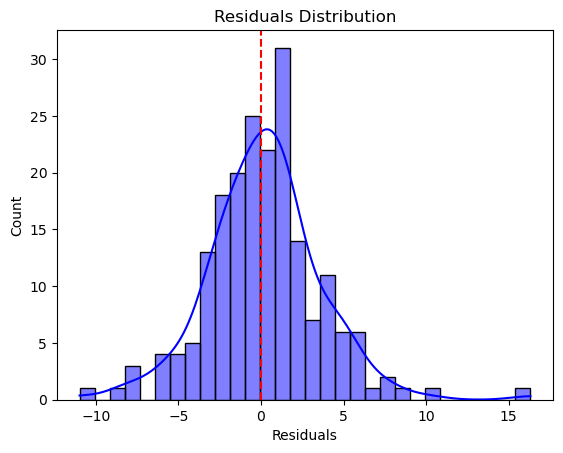

In [39]:
import seaborn as sns

sns.histplot(residuals, kde=True, bins=30, color='blue')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residuals")
plt.title("Residuals Distribution")
plt.show()


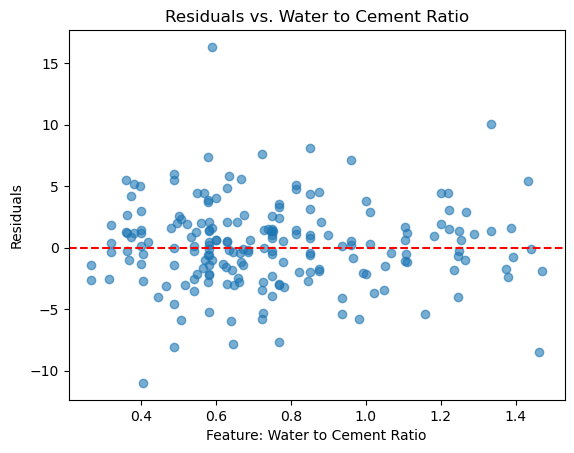

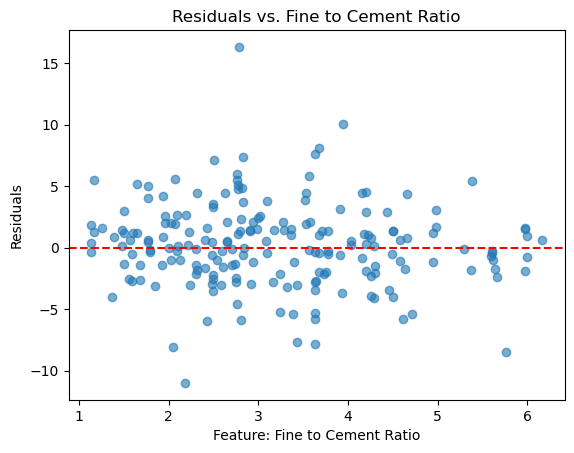

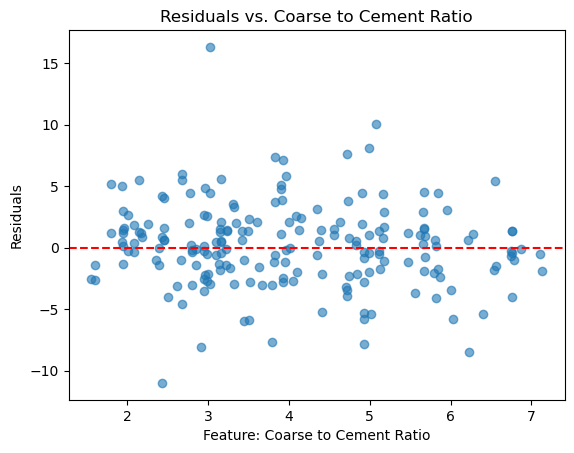

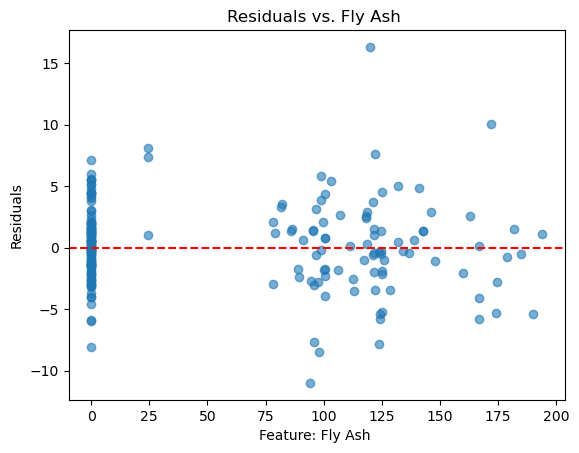

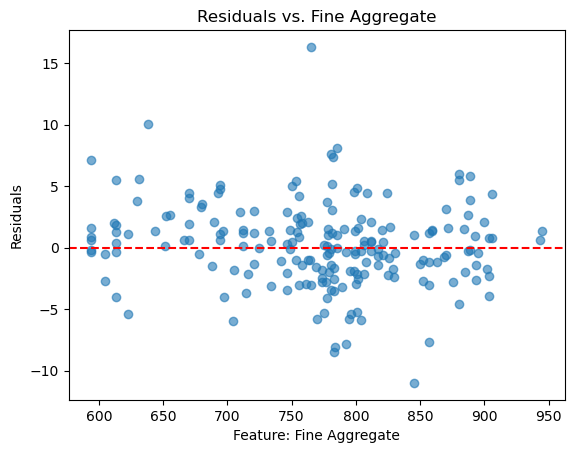

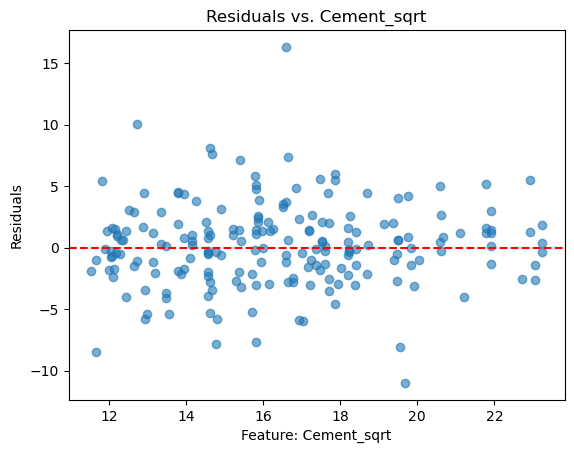

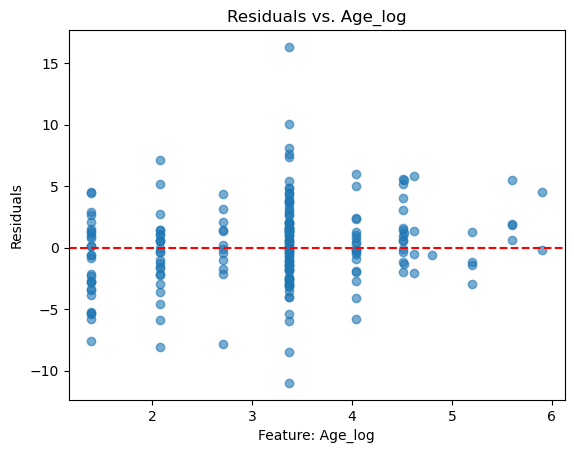

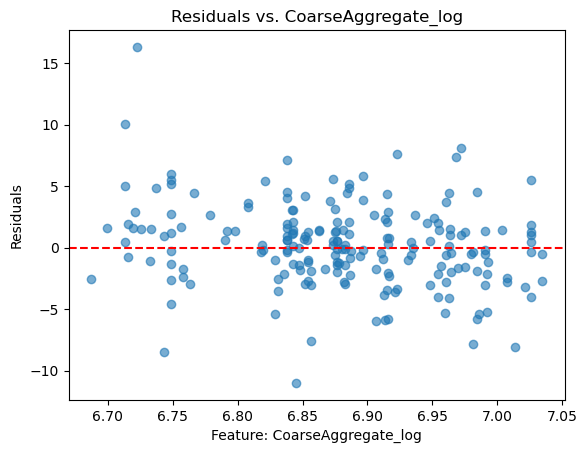

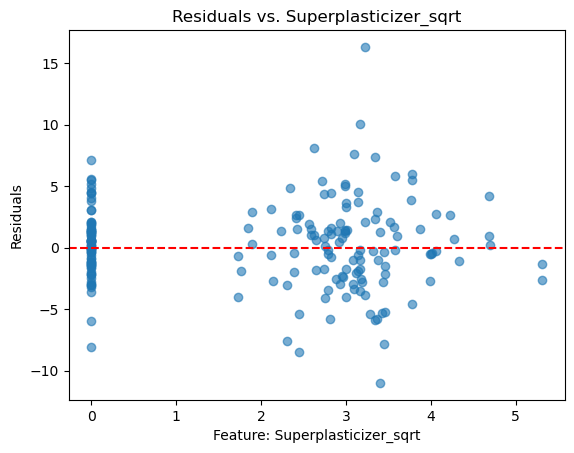

In [43]:
for i, column in enumerate(X_test.columns[:-2]):  # Skip "Actual" and "Predicted"
    plt.figure(i)
    plt.scatter(X_test[column], residuals, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel(f"Feature: {column}")
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs. {column}")
    plt.show()


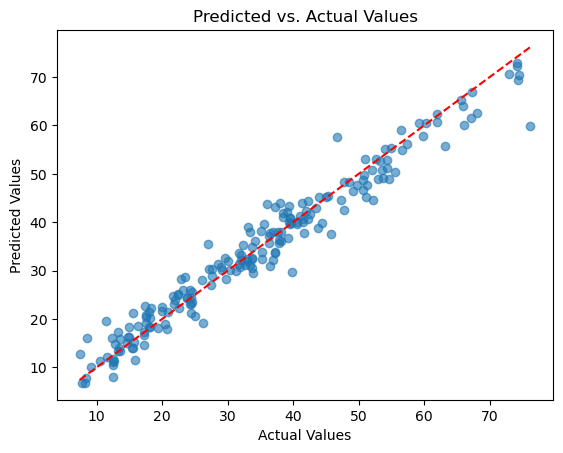

In [45]:
plt.scatter(y_test, y_pred_values, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Diagonal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs. Actual Values")
plt.show()


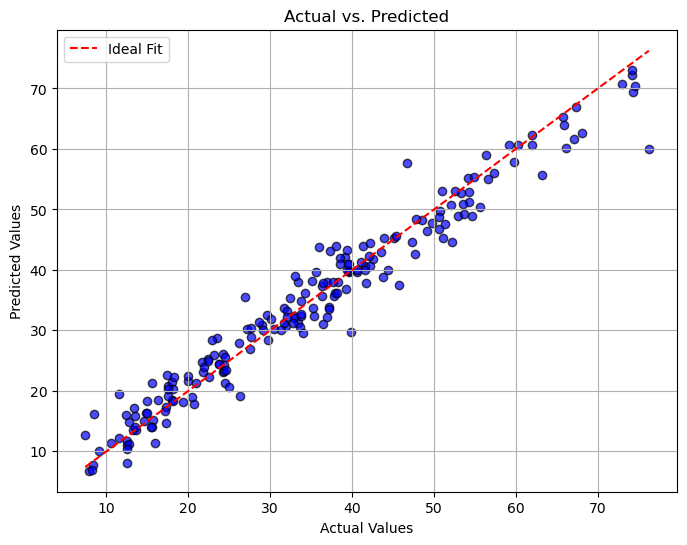

In [49]:
# Assuming `y_test` (actual values) and `predictions` (predicted values) are available

# 1. Scatter Plot: Actual vs. Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_values, color='blue', alpha=0.7, edgecolor='k')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Fit')
plt.title('Actual vs. Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()